### REPRESENTING TEXT AS NUMBERS

This is where NLP becomes particularly important for Machine Learning.

A machine-learning model doesn't understand:

"I loved the movie Spiderman"

We need to do below processing of the text

Text >> Numbers >> Machine Learning

##### we will demonstrate

1. One-hot encoding
2. Bag of Words
3. TF-IDF
4. Word2Vec (theory here, implemetation in lab case study)
5. GloVe (theory here, implemetation in lab case study)

In [ ]:
# install once
# %pip install scikit-learn

#### 1. One-hot Encoding

In [ ]:
# List of reviews
sentences = [
    "good the movie was good ",
    "the movie was very very good",
    "the movie was not good",
    "the film was bad",
    "bad bad movie with poor acting"
]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# convert sentences into word list
# class excercise - break down the code line below
words = sorted(list(set(" ".join(sentences).split())))

print(words)  # words is a list
print(len(words))

# reshape list of words to an array for encoder
words_array = np.array(words).reshape(-1, 1)  #This changes the shape into the format expected by OneHotEncoder
print(words_array)
print(words_array.shape)

encoder = OneHotEncoder(sparse_output=False)  # it creates the encoder object

# Fit the encoder object on the array of words. It learns the vocabulary and creates one-hot vectors.
one_hot_vectors = encoder.fit_transform(words_array) 

print("Vocabulary:", words)
print("One-hot array:", one_hot_vectors)
print("One-hot shape:", one_hot_vectors.shape)

In [ ]:
one_hot_vectors[0]# one hot vector of first word

#### 2. Bag of Words (BOW)

Now we move from representing individual words to representing sentences/documents
It shows "How many times does each word appear in a sentence?"

Example
Sentence 1:
good movie

Sentence 2:
bad movie

    bad good movie
             
Sentence 1:    0    1    1

Sentence 2:    1    0    1


In [ ]:
# CountVectorizer creates a Bag-of-Words representation.
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()  # CV object
X_count = cv.fit_transform(sentences)

print("Vocabulary:", cv.get_feature_names_out())
print("Matrix shape:", X_count.shape)

print(X_count.toarray())

Why is it called "Bag of Words"? and Limitations

Because it ignores much of the sentence structure.

Consider:

"Dog bites man."

and:

"Man bites dog."

Bag of Words sees approximately:

dog = 1
bites = 1
man = 1

for both.

It doesn't understand that the meaning changed because the order changed.

That's one major limitation.

### 3. TF-IDF
##### What is TF-IDF?

TF-IDF means:
Term Frequency – Inverse Document Frequency

##### The basic idea: Give more importance to words that are important to one document but not common across all documents.
Imagine three movie reviews.
Review 1: great acting movie
Review 2: boring movie
Review 3: excellent acting

The word movie isn't very useful if it appears everywhere.
But:
great
boring
excellent

can help distinguish documents.


<div>
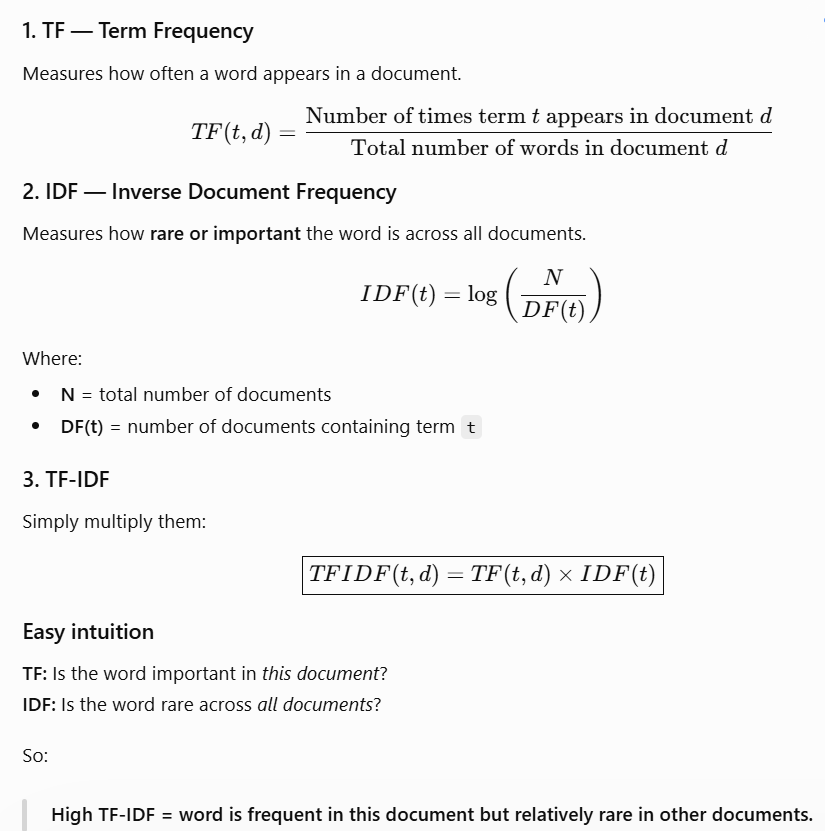
</div>


In [ ]:
# Import TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Dummy sentences
# sentences = [
#     "The cat sat on the mat.",
#     "The dog jumped over the fence.",
#     "The rat sat under the mat."
# ]

In [ ]:
sentences=["The truck moving on the road", "The dog is barking", "The clouds are in the sky"]

In [ ]:
# Initialize the TF-IDF vectorizer. Youare creating a TF-IDF machine and initializing it.
tfidf_vectorizer = TfidfVectorizer()

# Fit the vectorizer to the data and transform the sentences
# Fit will Learn all unique words.Transform will Convert every sentence into numbers.
tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)

# Get the feature names (words)
feature_names = tfidf_vectorizer.get_feature_names_out()

print(feature_names)

In [ ]:
tfidf_matrix
print(tfidf_matrix)

#### Why sparse matrices?

You may notice: tfidf_matrix doesn't look like a normal matrix. That's because NLP vocabulary can be huge.
Imagine:
10,000 documents
50,000 words

The matrix is:
10,000 × 50,000

But most documents contain only a tiny fraction of those 50,000 words.
Most cells are therefore zero.
Instead of storing millions of zeros, sklearn uses a sparse matrix.
This saves memory.

#### The matrix would look something like below
<div>
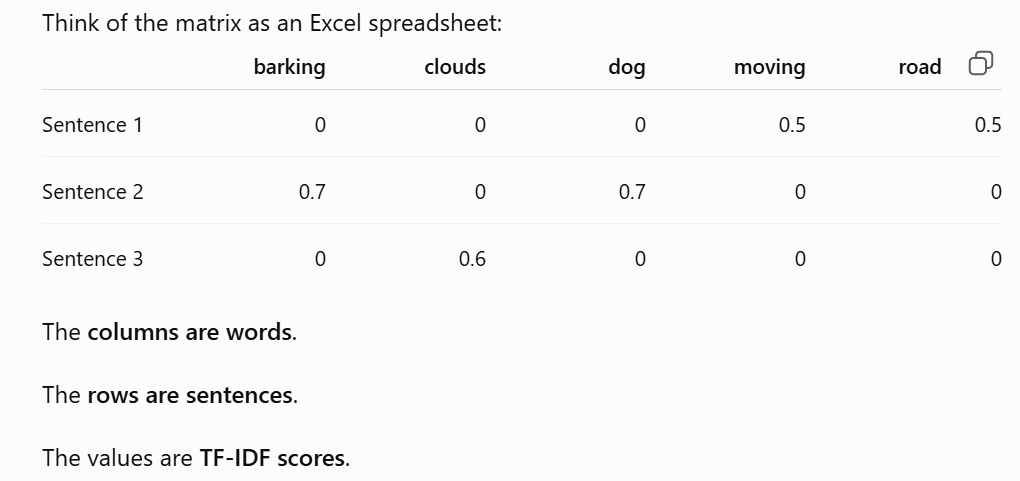
</div>

In [ ]:
# Calculate TF-IDF vector for each sentence
tfidf_vectors = []
for i, sentence in enumerate(sentences):
    tfidf_vector = np.round(tfidf_matrix[i].toarray().flatten(),decimals=2)
    tfidf_vectors.append(tfidf_vector)

# breakdown of np.round(tfidf_matrix[i].toarray().flatten(),decimals=2)
## tfidf_matrix[i] >> get row i
## toarray() >> convert the sparse matrix into a normal NumPy array
## flatten() >> turn it into a one-dimensional array
## lastly round the values to 2 decimal places

# # Convert list of TF-IDF vectors to numpy array
tfidf_vectors = np.array(tfidf_vectors)
tfidf_vectors

In [ ]:
print(sentences[1])
print()
print(tfidf_vectors[1].tolist())

# print(feature_names)

In [ ]:
len(tfidf_vectors[1].tolist())

#### WORD EMBEDDINGS
#### 4. WORD2VEC and 5. Glove

#### Now we move from simple word counting to word meaning. This is a major conceptual jump.

<u>Bag of Words / TF-IDF</u> - They mostly ask: "Does this word occur, what is the count and how important is it?"

<u> Word2Vec asks something more interesting: </u>- "What words tend to appear around this word?" <b> <i> That helps capture meaning. </i> </b>

<b>Word2Vec intuition</b>

Consider:
"The king sat on the throne."
and:
"The queen sat on the throne."
The words surrounding: king and queen are often similar

<i>Therefore Word2Vec learns vectors where related words are located relatively close together.</i>

Very simplified:

             king
              ●
            /   \
           /     \
       queen     throne
          ●         ●

The actual vectors have many dimensions — often 100, 300, etc.

<u>How Word2Vec actually learns :</u>
It's a simple neural network playing a game: "Given the words around a blank, guess the missing word." (...the movie was ___ amazing... → predict "truly"). After millions of guesses, the network's internal weights — one 50/100/200/300 (can be defined)-number set per word — become the word's meaning, because words appearing in similar contexts get similar weights.


We need a smarter representation

We want the computer to understand something like:

dog
 ↓
animal
 ↓
pet
 ↓
puppy

And:

king
 ↓
royalty
 ↓
queen
 ↓
prince

<b>We want words with related meanings to have similar numerical representations.</b>

This is where word embeddings come in.


#### What is a Word Embedding?
Representing a word using a list of numbers (a vector) in such a way that the numbers capture aspects of its meaning.

For example, imagine:

dog → [0.82, 0.31, 0.76, 0.12]
cat → [0.79, 0.34, 0.71, 0.15]
car → [0.12, 0.91, 0.08, 0.67]

The numbers themselves don't have obvious meanings like:

0.82 = animal
0.31 = furry

Don't think of them that way.

Instead, think:
<u>
The overall pattern of numbers represents the word's position in a mathematical "meaning space."
</u>
-------------------------------------------------------------------------------------------

This is the easiest way to understand embeddings.

Imagine a map where:

             dog ●
                ● cat
               
                       ● horse


                                    ● car

Animals are relatively close to each other.
Cars are somewhere else.

So:

dog ↔ cat

are close.

But:

dog ↔ car

are far apart.

This is essentially what an embedding is doing.

<u>But how can a computer create this map?</u>

<b>Here's the brilliant idea behind Embeddings (Word2Vec/ Glove): </b>

A word's meaning can be learned from the words that appear around it. This is the fundamental idea you MUST understand.
There is a famous linguistic principle:
Words that occur in similar contexts tend to have similar meanings.
You don't need to memorize the fancy name.
Just remember:
"You understand a word by the company it keeps."

Example

Consider:
The dog is playing in the park.
Look at: dog

What words are around it?

the , is , playing

Now:
The cat is playing in the park.
Around: cat
we see:

the, is, playing

The contexts are similar.

Therefore:

dog ≈ cat

#### But HOW does Word2Vec actually learn?

There are two famous Word2Vec approaches:
1. CBOW
2. Skip-gram

#### 1. CBOW- Continuous Bag of Words
Its idea is:
<i>Use surrounding words to predict the missing/target word.</i>

Consider:
"The cat is sitting on the mat."

Suppose we're trying to predict: cat

We give the model surrounding words:

The __________ is

     ????
     
       ↓
      cat

The model learns:

"The" + "is" → cat

##### Note-in real Word2Vec the context window can contain more words.

#### Why does this create meaningful vectors?
Suppose the model sees:

Sentence1- The dog is running.

Sentence2- The cat is running.

Sentence3- The horse is running.

To predict: dog
it sees contexts such as:

The ___ is running

For: cat
it sees almost the same context.

Therefore, during training, the model adjusts the vectors so that:

dog ≈ cat ≈ horse

That's the mathematical idea.

##### Skip-gram does the opposite
Skip-gram says: Take the target word and predict the surrounding words.

Example:
The dog is running
Target: dog

The model tries to predict:
The
is
running

So:

             dog
           /  |  \
          ↓   ↓   ↓
        The  is running
        
Remember this:
CBOW:
Context → Target word

Skip-gram:
Target word → Context words

That's it.

#### Why is it called "training"?

Suppose the model initially has completely random vectors:

dog → [0.01, 0.91, -0.21...]
cat → [-0.82, 0.11, 0.45...]

It makes predictions. Some predictions are wrong. It calculates the error. Then it adjusts the numbers (backpropgation).

Again.
Again.
Again.
Millions of times.

Eventually, words appearing in similar contexts develop similar vectors.

So:

Training
   ↓
Prediction
   ↓
Error
   ↓
Adjust vectors
   ↓
Prediction
   ↓
Error
   ↓
Adjust vectors
   ↓
...
   ↓
Meaningful word vectors

<u> Note- You don't need to understand neural-network mathematics yet to understand the concept. </u>

#### In summary - remember - 
Words that appear in similar contexts tend to have similar meanings. "dog" and "cat" both appear near words like "pet," "vet," "bark/meow," "feed." 

<b>Word2vec and GloVe just differ in how they exploit this idea:</b>

<u>Word2vec: </u> a neural network that predicts context words from a target word (or vice versa), and the learned weights become the embeddings.

<u>GloVe: </u> directly factorizes a global word co-occurrence matrix — how often word A appears near word B across the whole corpus.

#### Word2Vec vs GloVe — simple analogy

Imagine you want to understand students in a school.

Word2Vec
You follow students around and observe:

"Who is this student hanging around with?"
You learn relationships from local context/windows.

GloVe
You collect the entire school's attendance/social interaction table.

You ask:
"How often does Student A interact with Student B across the whole school?"
You use global word co-occurrence information.

That's the key distinction.

#### What is co-occurrence?

"Co-occurrence" simply means:
Two words appearing together or near each other.

Consider:

I drink coffee.
I drink tea.
I like coffee.

We can count how often words appear near each other.

For example:

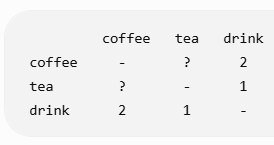

This is called a co-occurrence matrix.
GloVe uses this type of global information

#### Why is GloVe called "Global"?
Because it uses information from the whole corpus.

Imagine you have: 1 million documents

GloVe builds/uses statistics about how words co-occur throughout that corpus.
while 
Word2Vec primarily learns through its training examples and local context windows.

GloVe explicitly leverages global co-occurrence statistics.

#### Why do we need pre-trained GloVe?

Here's another important concept from your notebook.

Imagine you have only:

500 movie reviews

That's not a lot of text to train a powerful word embedding model.

Instead, somebody has already trained GloVe on a huge corpus.

You download the pre-trained vectors.

Then:

GloVe
 
 ↓
"action" → vector
"movie" → vector
"romantic" → vector
"boring" → vector

You don't have to train the embeddings yourself.

This is called: Transfer learning / using pre-trained embeddings